Loading Shapefile

In [7]:
import geopandas as gpd

tracts = gpd.read_file("../../data/raw/census/tl_2023_11_tract/tl_2023_11_tract.shp")

tracts = tracts.to_crs(epsg=4326)

tracts.head()


,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,11,001,005302,11001005302,1400000US11001005302,53.02,Census Tract 53.02,G5020,S,117635,0,+38.9124517,-077.0386443,"POLYGON ((-77.04167 38.91153, -77.04135 38.911..."
1,11,001,004402,11001004402,1400000US11001004402,44.02,Census Tract 44.02,G5020,S,274746,0,+38.9155152,-077.0270354,"POLYGON ((-77.03195 38.91629, -77.03195 38.916..."
2,11,001,010602,11001010602,1400000US11001010602,106.02,Census Tract 106.02,G5020,S,542512,0,+38.9033936,-076.9994636,"POLYGON ((-77.00443 38.90252, -77.00415 38.903..."
3,11,001,000804,11001000804,1400000US11001000804,8.04,Census Tract 8.04,G5020,S,2566768,167978,+38.9221746,-077.0918347,"POLYGON ((-77.10517 38.91725, -77.10515 38.917..."
4,11,001,003902,11001003902,1400000US11001003902,39.02,Census Tract 39.02,G5020,S,266513,11205,+38.9257717,-077.0452397,"POLYGON ((-77.0498 38.92788, -77.04967 38.9280..."


Mapping the cencus tracts

<Axes: >

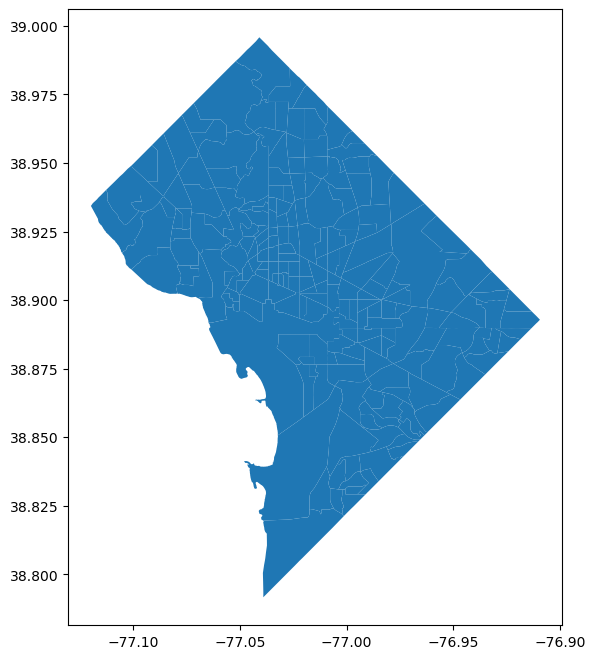

In [8]:
tracts.plot(figsize=(8, 8))

Clipping the tracts to Foggy Bottom area

<Axes: >

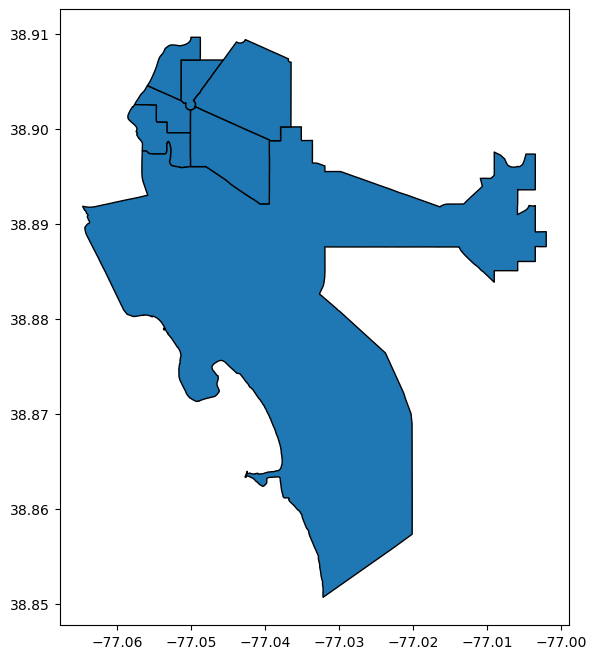

In [9]:
import shapely.geometry as geom

foggy_bottom_bbox = geom.box(-77.055, 38.889, -77.045, 38.905)

foggy_bottom = tracts[tracts.intersects(foggy_bottom_bbox)]

foggy_bottom.plot(figsize=(8, 8), edgecolor="black")


In [16]:
CENSUS_KEY = "1ef37f056d91a9e24b45c530729a923877bd6245"

In [17]:
import requests
import pandas as pd

def get_acs(table, variables):
    base = "https://api.census.gov/data/2023/acs/acs5"
    var_string = ",".join(variables)
    
    url = (
        f"{base}?get=NAME,{var_string}"
        "&for=tract:*"
        "&in=state:11"
        "&in=county:001"
        f"&key={CENSUS_KEY}"
    )
    
    response = requests.get(url)
    print("Status:", response.status_code)
    print("Preview:", response.text[:200])  # debug
    
    return pd.DataFrame(response.json()[1:], columns=response.json()[0])


In [13]:
print(CENSUS_KEY)


1ef37f056d91a9e24b45c530729a923877bd6245


In [19]:
# Population (B01003)
pop = get_acs("B01003", ["B01003_001E"])



Status: 200
Preview: [["NAME","B01003_001E","state","county","tract"],
["Census Tract 1.01; District of Columbia; District of Columbia","1181","11","001","000101"],
["Census Tract 1.02; District of Columbia; District of C


In [20]:
# Race (B02001)
race = get_acs("B02001", [
    "B02001_001E",  # total
    "B02001_002E",  # white
    "B02001_003E",  # black
    "B02001_005E",  # asian
])



Status: 200
Preview: [["NAME","B02001_001E","B02001_002E","B02001_003E","B02001_005E","state","county","tract"],
["Census Tract 1.01; District of Columbia; District of Columbia","1181","888","58","37","11","001","000101"]


In [21]:
#Income (B19013)
income = get_acs("B19013", ["B19013_001E"])


Status: 200
Preview: [["NAME","B19013_001E","state","county","tract"],
["Census Tract 1.01; District of Columbia; District of Columbia","135708","11","001","000101"],
["Census Tract 1.02; District of Columbia; District of


In [22]:
# Education (B15003)
education = get_acs("B15003", [
    "B15003_017E",  # high school
    "B15003_022E",  # bachelor's
    "B15003_023E",  # master's
    "B15003_025E",  # doctorate
])


Status: 200
Preview: [["NAME","B15003_017E","B15003_022E","B15003_023E","B15003_025E","state","county","tract"],
["Census Tract 1.01; District of Columbia; District of Columbia","23","398","272","103","11","001","000101"]


In [23]:
# Housing (B25077)
housing = get_acs("B25077", ["B25077_001E"])

Status: 200
Preview: [["NAME","B25077_001E","state","county","tract"],
["Census Tract 1.01; District of Columbia; District of Columbia","610000","11","001","000101"],
["Census Tract 1.02; District of Columbia; District of


In [24]:
#Employment (B23025)
employment = get_acs("B23025", [
    "B23025_002E",  # labor force
    "B23025_004E",  # employed
    "B23025_005E",  # unemployed
])

Status: 200
Preview: [["NAME","B23025_002E","B23025_004E","B23025_005E","state","county","tract"],
["Census Tract 1.01; District of Columbia; District of Columbia","745","728","17","11","001","000101"],
["Census Tract 1.0


In [25]:
def add_geoid(df):
    df["GEOID"] = df["state"] + df["county"] + df["tract"]
    return df

In [26]:
pop = add_geoid(pop)
race = add_geoid(race)
income = add_geoid(income)
education = add_geoid(education)
housing = add_geoid(housing)
employment = add_geoid(employment)

In [28]:
pop = pop[["GEOID", "B01003_001E"]]

race = race[[
    "GEOID",
    "B02001_001E",
    "B02001_002E",
    "B02001_003E",
    "B02001_005E"
]]

income = income[["GEOID", "B19013_001E"]]

education = education[[
    "GEOID",
    "B15003_017E",
    "B15003_022E",
    "B15003_023E",
    "B15003_025E"
]]

housing = housing[["GEOID", "B25077_001E"]]

employment = employment[[
    "GEOID",
    "B23025_002E",
    "B23025_004E",
    "B23025_005E"
]]


Merging all ACS tables into one DataFrame

In [29]:
acs = (
    pop[["GEOID", "B01003_001E"]]
    .merge(race, on="GEOID")
    .merge(income, on="GEOID")
    .merge(education, on="GEOID")
    .merge(housing, on="GEOID")
    .merge(employment, on="GEOID")
)

Joining ACS to tracts

In [30]:
tracts_acs = tracts.merge(acs, on="GEOID", how="left")

Creating derived variables

Raw ACS counts are useful, but they don’t tell a story until we convert them into percentages, rates, and ratios. These are the variables that make your maps and analysis meaningful.


In [32]:
for col in acs.columns:
    acs[col] = pd.to_numeric(acs[col], errors="coerce")

In [33]:
acs["pct_white"] = acs["B02001_002E"] / acs["B02001_001E"]
acs["pct_black"] = acs["B02001_003E"] / acs["B02001_001E"]
acs["pct_asian"] = acs["B02001_005E"] / acs["B02001_001E"]

acs["pct_bachelors"] = acs["B15003_022E"] / (
    acs["B15003_017E"] +
    acs["B15003_022E"] +
    acs["B15003_023E"] +
    acs["B15003_025E"]
)

acs["unemployment_rate"] = acs["B23025_005E"] / acs["B23025_002E"]


In [35]:
acs["GEOID"] = acs["GEOID"].astype(str)
tracts["GEOID"] = tracts["GEOID"].astype(str)

In [36]:
#Joining derived variables to tracts
tracts_acs = tracts.merge(acs, on="GEOID", how="left")

<Axes: >

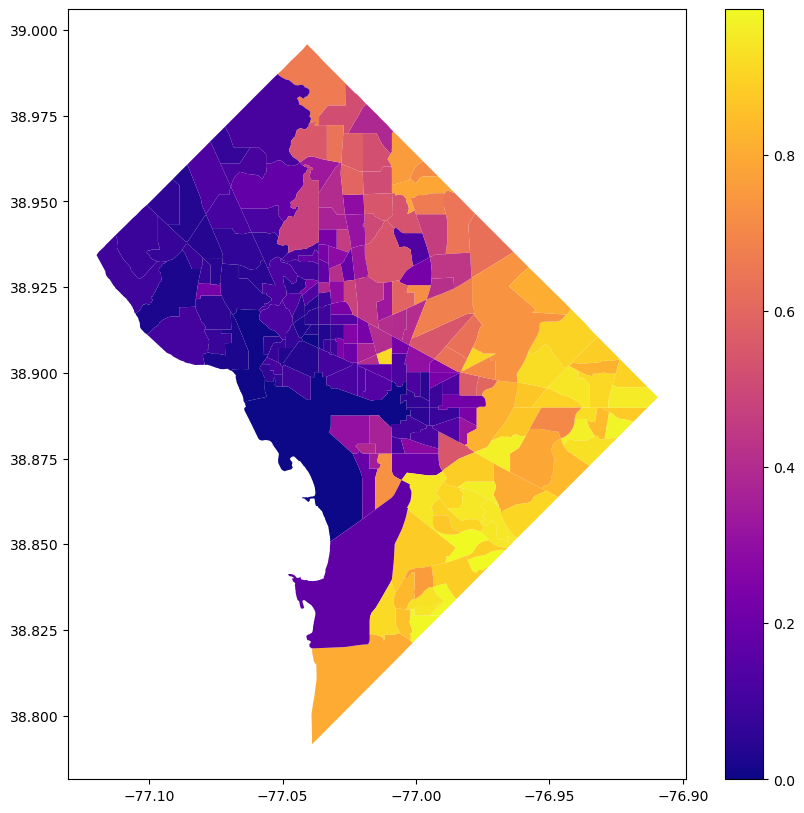

In [37]:
tracts_acs.plot(
    column="pct_black",
    cmap="plasma",
    legend=True,
    figsize=(10, 10)
)


In [45]:
import os

os.makedirs("data/processed", exist_ok=True)


In [46]:
tracts_acs.to_parquet("data/processed/acs_merged.parquet")

In [47]:
import geopandas as gpd
test = gpd.read_parquet("data/processed/acs_merged.parquet")
test.head()


,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,...,B15003_025E,B25077_001E,B23025_002E,B23025_004E,B23025_005E,pct_white,pct_black,pct_asian,pct_bachelors,unemployment_rate
0,11,001,005302,11001005302,1400000US11001005302,53.02,Census Tract 53.02,G5020,S,117635,...,108,497300,1975,1959,0,0.766392,0.033765,0.096977,0.526190,0.000000
1,11,001,004402,11001004402,1400000US11001004402,44.02,Census Tract 44.02,G5020,S,274746,...,129,1022400,1810,1690,104,0.633640,0.139033,0.060328,0.400265,0.057459
2,11,001,010602,11001010602,1400000US11001010602,106.02,Census Tract 106.02,G5020,S,542512,...,417,992100,5294,5112,169,0.541478,0.304168,0.058605,0.359153,0.031923
3,11,001,000804,11001000804,1400000US11001000804,8.04,Census Tract 8.04,G5020,S,2566768,...,174,1891400,1529,1454,52,0.841733,0.022933,0.030294,0.440000,0.034009
4,11,001,003902,11001003902,1400000US11001003902,39.02,Census Tract 39.02,G5020,S,266513,...,104,578400,1324,1315,0,0.560316,0.051297,0.173055,0.435368,0.000000
